## Table of contents

1. [**Inspecting Data**](#andmetesse_sissevaatamine)
2. [**Evaluation Vabamorf**](#hindamine_vabamorf)
3. [**Results Vabamorf (first)**](#tulemused_vabamorf_first)
4. [**Results Vabamorf (random)**](#tulemused_vabamorf_random)

[end](#end)


### Conclusive evaluation results for the model

> Note that the evaluation results are based on only the form label pairs, and thus do not take into account the POS tags.

| Model             | Accuracy | Precision | Recall | F1-score |
| ----------------- | -------: | --------: | -----: | -------: |
| Vabamorf (first)  |   83.30% |    82.93% | 83.30% |   83.01% |
| Vabamorf (random) |   83.31% |    82.94% | 83.31% |   83.02% |


### Imports


In [7]:
print("Test")

Test


In [8]:
import os
import evaluate
import re
import random
import math
import pandas as pd
import numpy as np
import estnltk, estnltk.converters, estnltk.taggers
import sklearn
import sklearn.metrics

from typing import Any, Tuple, Optional

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

from tqdm import tqdm
from scripts.model.bert_morph_tagger import BertMorphTagger
from scripts.notebooks.NotebookFunctions import (
    _extract_prediction_from_layer,
    annotate_sentences_with_model,
    display_metrics_and_classification_report,
    plot_confusion_matrices,
    plot_true_vs_pred_by_inflection,
    display_examples,
    create_lenient_labels_and_split_counts_and_cases,
)

from scripts.config import (
    SEED,
    ROOT,
    DATA_DIR,
    ENC2017_ROOT,
    UD_ET_EDT_ROOT,
    HOMONYMS_ROOT,
    ENC2017_DIRS,
    UD_ET_EDT_DIRS,
    HOMONYMS_DIRS,
    OUTPUT_DIR,
    PLOTS_DIR,
    HOMONYMS_PLOTS_DIR,
    MODEL_DIR,
)

<a id='andmetesse_sissevaatamine'></a>


### Inspecting Data


In [ ]:
overall_df = pd.read_parquet(
    HOMONYMS_DIRS["processed"] / "homonyms_overall_updated_sentences.parquet"
)

In [ ]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"[51, 60]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"[16, 20]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"[0, 7]",[sg g],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


In [ ]:
import numpy as np

# Convert list/array inflection types to tuples for consistent grouping
overall_df["label"] = overall_df["label"].apply(
    lambda x: tuple(x) if isinstance(x, (list, np.ndarray)) else x
)

display(
    overall_df.groupby(["inflection_type", "label"])
    .size()
    .reset_index()
    .sort_values(by="inflection_type")
)

,inflection_type,label,0
0,1,"(sg g,)",1232
1,1,"(sg n,)",764
2,16,"(sg g,)",1080
3,16,"(sg n,)",890
4,17,"(sg g,)",524
5,17,"(sg n,)",791
6,17,"(sg p,)",609
7,19,"(adt,)",94
8,19,"(sg g,)",1621
9,19,"(sg p,)",281


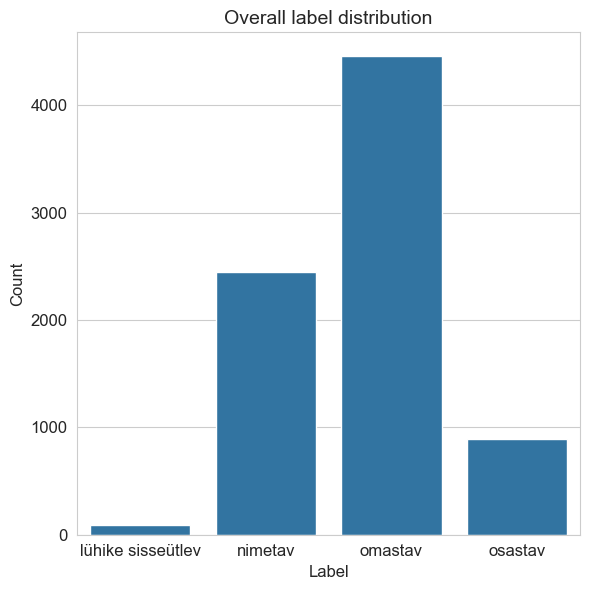

INFO:category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


C:\Users\Admin\AppData\Local\Temp\ipykernel_32032\3500709682.py:38: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.countplot(


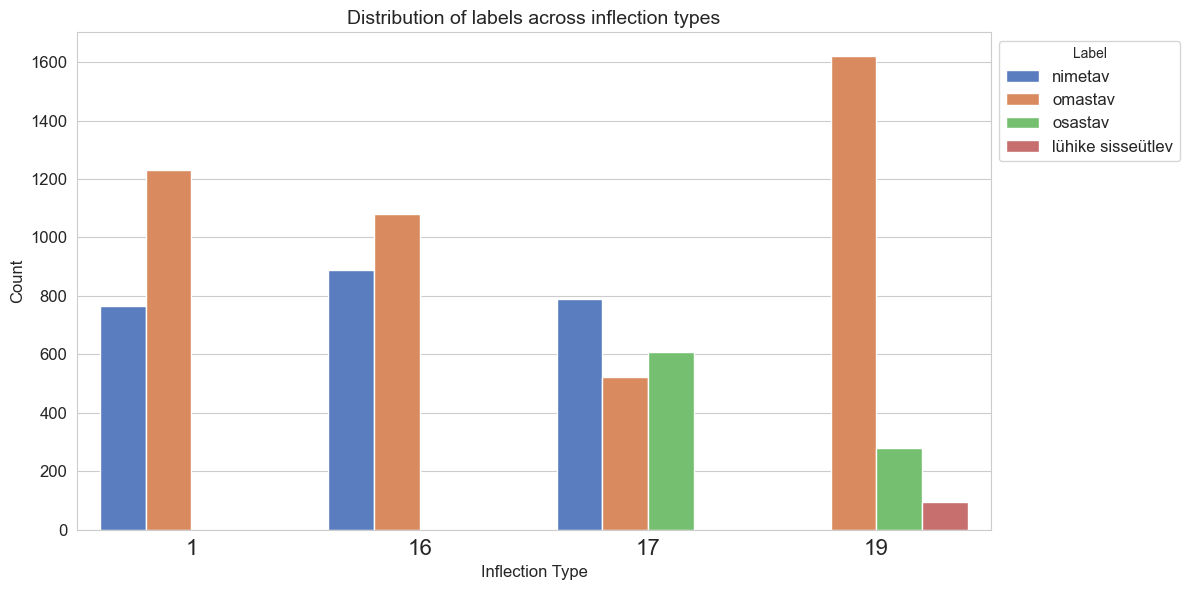

In [ ]:
overall_df["label_str"] = overall_df["label"].apply(lambda x: x[0])

# Rename the labels for better readability in plots
label_mapping = {
    "sg n": "nimetav",
    "sg g": "omastav",
    "sg p": "osastav",
    "adt": "lühike sisseütlev",
}
overall_df["label_str"] = (
    overall_df["label_str"].map(label_mapping).fillna(overall_df["label_str"])
)

# Plot label distribution
sns.set_style("whitegrid")
plt.figure(figsize=(6, 6))
sns.countplot(
    data=overall_df,
    x="label_str",
    order=sorted(overall_df["label_str"].dropna().unique()),
)
plt.title("Overall label distribution", fontsize=14)
plt.xlabel("Label", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(
    str(HOMONYMS_PLOTS_DIR / "overall_label_distribution.png"),
    dpi=300,
)
plt.show()

# Plot label distribution across inflection types
sns.set_style("whitegrid")
palette = sns.color_palette("muted")
plt.figure(figsize=(12, 6))
sns.countplot(
    data=overall_df,
    x="inflection_type",
    hue="label_str",
    palette=palette,
    order=sorted(overall_df["inflection_type"].dropna().unique()),
)
plt.title("Distribution of labels across inflection types", fontsize=14)
plt.xlabel("Inflection Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=16)
plt.yticks(fontsize=12)
plt.legend(title="Label", bbox_to_anchor=(1, 1), loc="upper left", fontsize=12)
plt.tight_layout()
plt.savefig(
    str(HOMONYMS_PLOTS_DIR / "label_distribution_by_inflection_type.png"),
    dpi=300,
)
plt.show()

In [ ]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"[51, 60]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"[16, 20]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"[0, 7]","(sg g,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


<a id='hindamine_vabamorf'></a>


### Evaluation Vabamorf


In [11]:
model_path = "Vabamorf"
model_name = "Vabamorf"
df_first_output_csv_path = str(
    HOMONYMS_DIRS["annotations"] / "homonyms_annotations_Vabamorf_first.csv"
)
df_random_output_csv_path = str(
    HOMONYMS_DIRS["annotations"] / "homonyms_annotations_Vabamorf_random.csv"
)

In [ ]:
results_df = annotate_sentences_with_model(
    input_df=overall_df,
    model_name=model_path,
    output_csv_path=df_first_output_csv_path,
    progress_desc="Evaluating Vabamorf (choosing first) on homonyms dataset",
    vabamorf_random_or_first="first",
)

Evaluating Vabamorf (choosing first) on homonyms dataset: 100%|██████████| 7886/7886 [00:58<00:00, 134.75it/s]


In [ ]:
display(results_df.head())

,sentence,word,word_span,true_label,pred_label,ambiguous,num,inflection_type
0,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"(74, 80)",sg n,sg n,False,1,1
1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"(20, 27)",sg n,sg n,False,1,1
2,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"(51, 60)",sg n,sg n,False,1,1
3,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"(16, 20)",sg n,sg n,False,1,1
4,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"(0, 7)",sg g,sg g,False,1,1


In [ ]:
results_df = annotate_sentences_with_model(
    input_df=overall_df,
    model_name=model_path,
    output_csv_path=df_random_output_csv_path,
    progress_desc="Evaluating Vabamorf (choosing random) on homonyms dataset",
    vabamorf_random_or_first="random",
)

Evaluating Vabamorf (choosing random) on homonyms dataset: 100%|██████████| 7886/7886 [00:55<00:00, 140.91it/s]


In [ ]:
display(results_df.head())

,sentence,word,word_span,true_label,pred_label,ambiguous,num,inflection_type
0,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"(74, 80)",sg n,sg n,False,1,1
1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"(20, 27)",sg n,sg n,False,1,1
2,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"(51, 60)",sg n,sg n,False,1,1
3,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"(16, 20)",sg n,sg n,False,1,1
4,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"(0, 7)",sg g,sg g,False,1,1


<a id='tulemused_vabamorf_first'></a>


### Results Vabamorf (first)


In [17]:
model_name = "Vabamorf_first"

In [18]:
# Load results dataframe
results_df = pd.read_csv(
    df_first_output_csv_path,
    index_col=False,
)

results_df_split, results_df_filtered = (
    create_lenient_labels_and_split_counts_and_cases(
        results_df, "true_label", "pred_label"
    )
)

results_df_filtered_possibles = results_df_filtered[
    (results_df_filtered["true_case_lenient"] != "other")
    & (results_df_filtered["pred_case_lenient"] != "other")
]

print(f"{model_name} results:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)
print(f"\n{model_name} results (lenient):")
display_metrics_and_classification_report(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    show_metrics=True,
    show_classification_report=False,
)
print(f"\n{model_name} results (lenient, excluding 'other'):")
display_metrics_and_classification_report(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    show_metrics=True,
    show_classification_report=False,
)

# Count cases where "other" was predicted and the proportion of those out of all predictions
other_pred_count = (results_df_filtered["pred_case_lenient"] == "other").sum()
total_pred_count = len(results_df_filtered)
print(
    f'\nNumber of "other" cases: {other_pred_count} out of {total_pred_count} ({other_pred_count / total_pred_count:.2%})'
)

Vabamorf_first results:
Overall results
Accuracy:  83.30%
Precision: 82.93%
Recall:    83.30%
F1-score:  83.01%

Vabamorf_first results (lenient):
Overall results
Accuracy:  83.31%
Precision: 82.94%
Recall:    83.31%
F1-score:  83.02%

Vabamorf_first results (lenient, excluding 'other'):
Overall results
Accuracy:  83.34%
Precision: 82.94%
Recall:    83.34%
F1-score:  83.03%

Number of "other" cases: 3 out of 7886 (0.04%)


In [19]:
# Print classification reports
print(f"{model_name} classification report:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=False,
    show_classification_report=True,
)

Vabamorf_first classification report:
Overall results - Classification Report
              precision    recall  f1-score   support

         adt       0.47      0.29      0.36        94
           o       0.00      0.00      0.00         0
        pl p       0.00      0.00      0.00         0
       sg es       0.00      0.00      0.00         0
        sg g       0.86      0.90      0.88      4457
        sg n       0.83      0.80      0.82      2445
        sg p       0.72      0.63      0.67       890

    accuracy                           0.83      7886
   macro avg       0.41      0.37      0.39      7886
weighted avg       0.83      0.83      0.83      7886



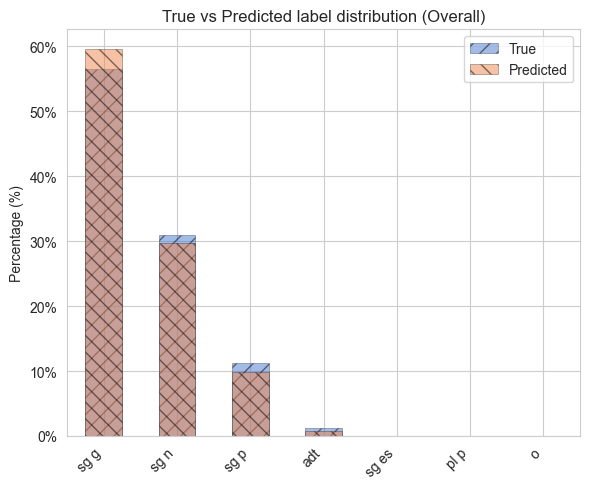

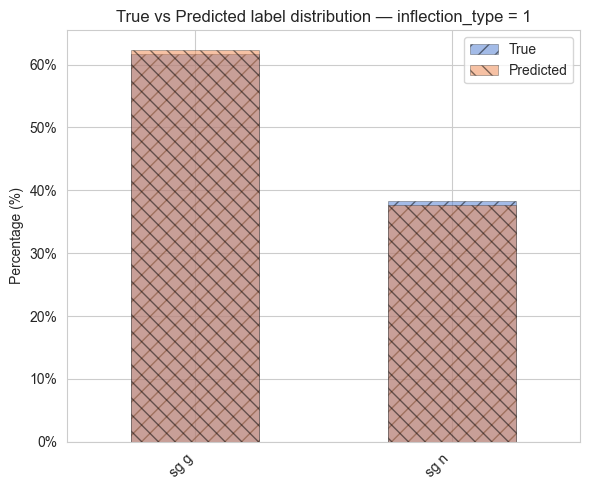

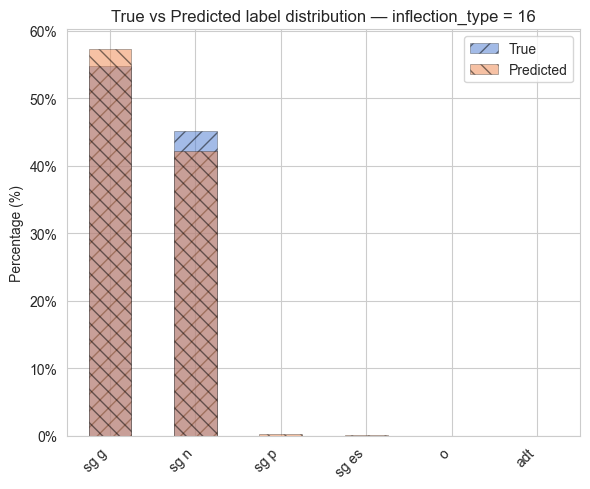

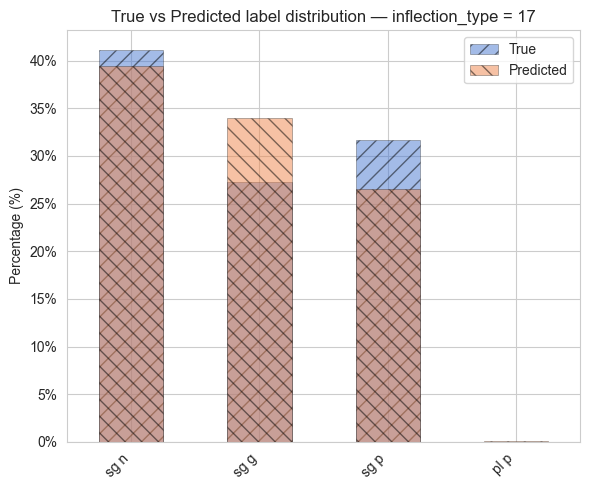

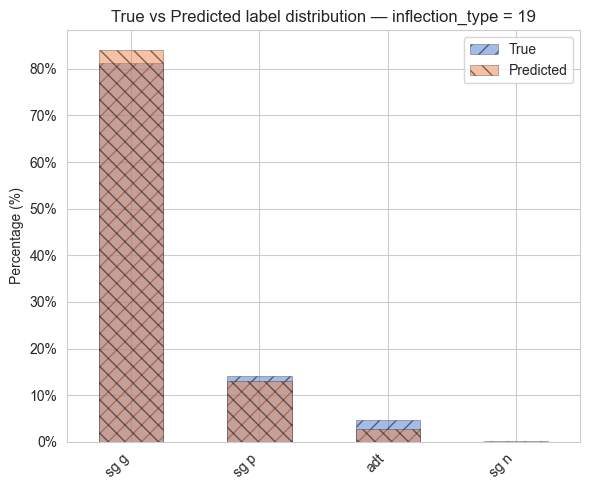

In [20]:
plot_true_vs_pred_by_inflection(
    results_df,
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar",
)

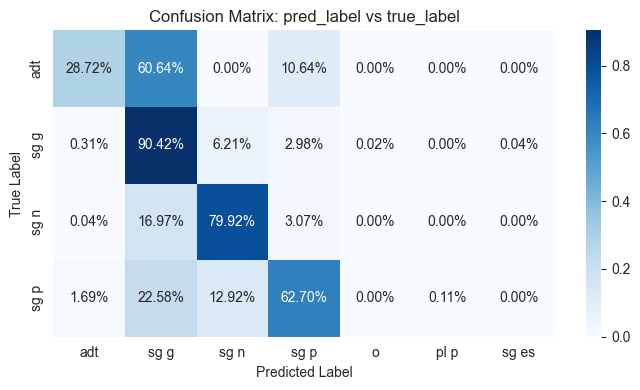

Confusion Matrix: pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                sg es      2       0.03              True              0
1                    o      1       0.01              True              0
2                 pl p      1       0.01              True              0
Sum of true labels count: 7886


In [22]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    fig_size=(7, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM.png"),
    significant_pred_threshold_pct=0,
)

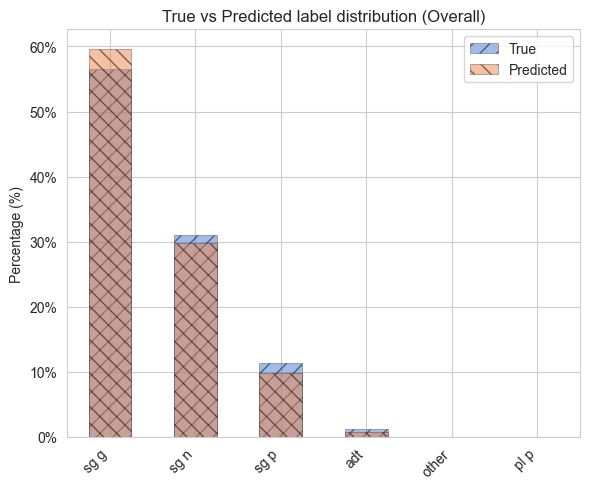

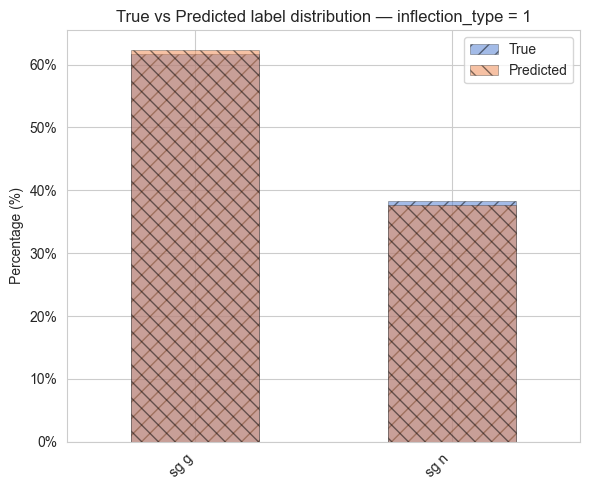

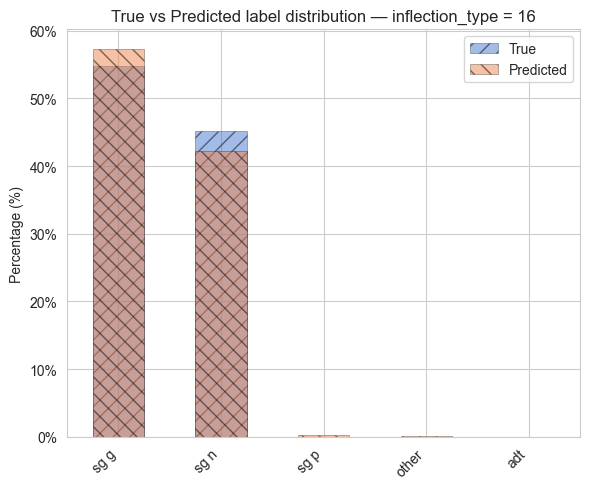

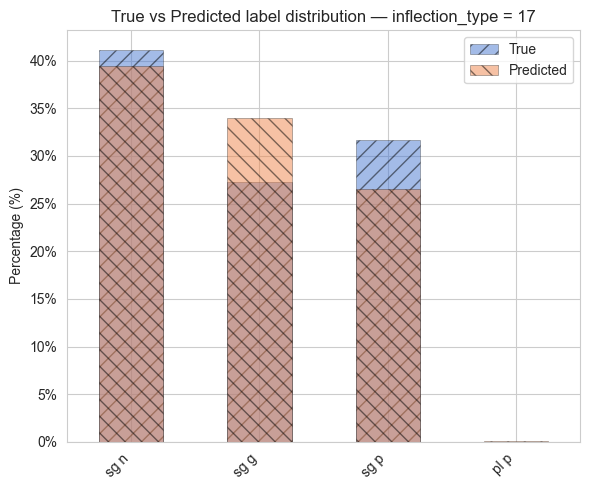

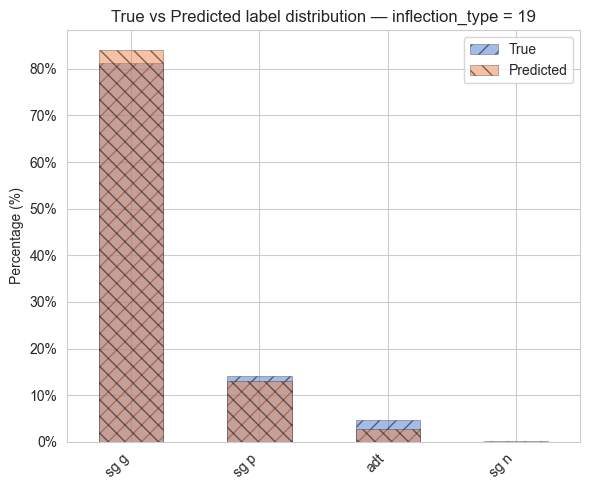

In [23]:
plot_true_vs_pred_by_inflection(
    results_df_filtered,
    label_col="true_label_lenient",
    pred_col="pred_label_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_lenient_bar",
)

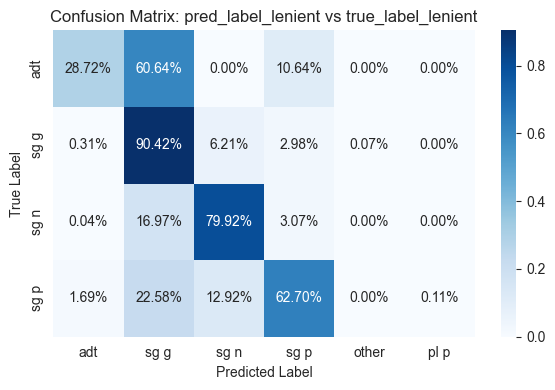

Confusion Matrix: pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other      3       0.04              True              0
1                 pl p      1       0.01              True              0
Sum of true labels count: 7886


In [24]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_label_lenient",
    true_col="true_label_lenient",
    fig_size=(6, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient.png"),
    significant_pred_threshold_pct=0,
)

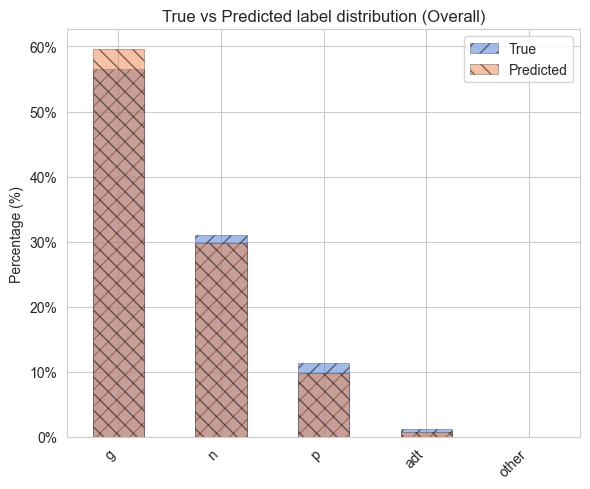

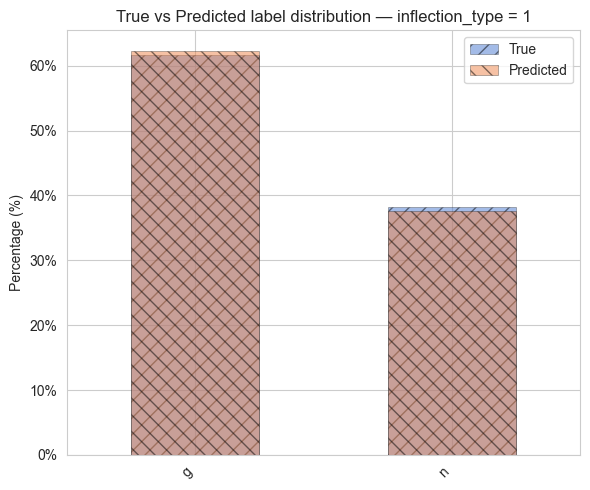

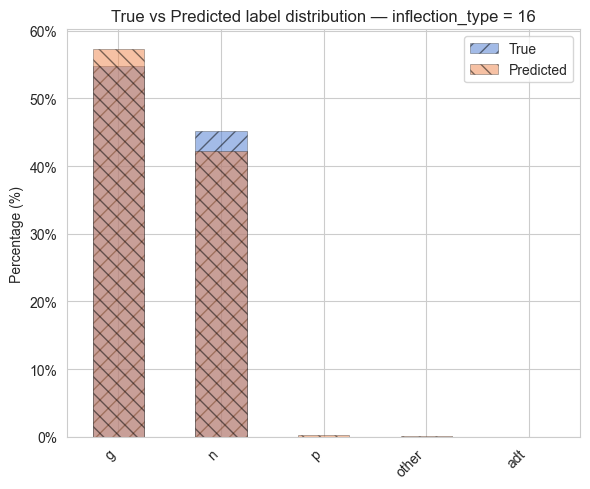

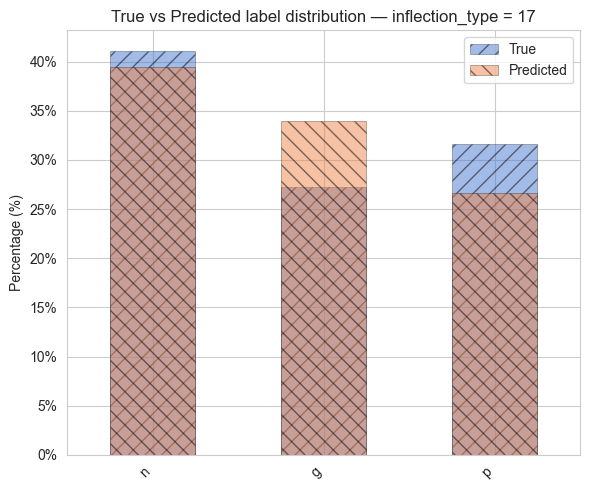

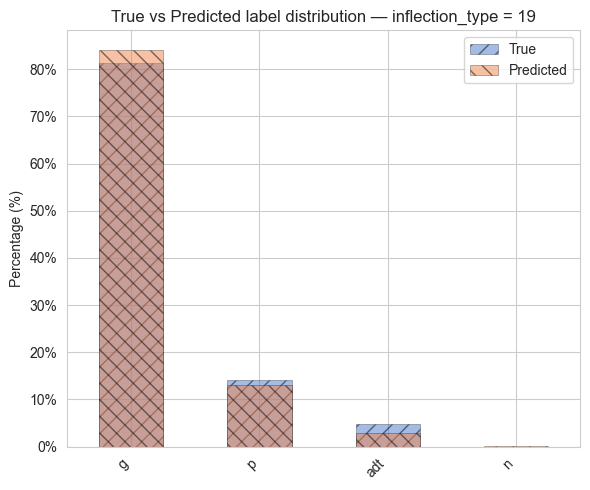

In [25]:
plot_true_vs_pred_by_inflection(
    results_df_filtered,
    label_col="true_case_lenient",
    pred_col="pred_case_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar_lenient_case",
)

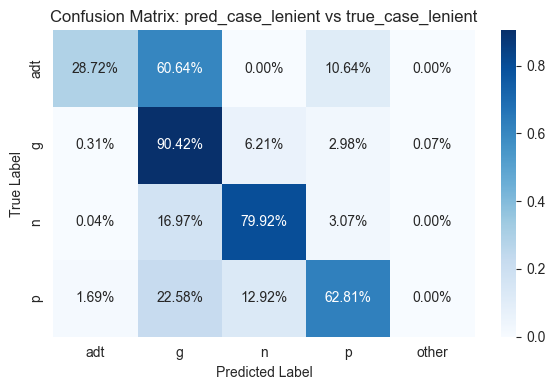

Confusion Matrix: pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other      3       0.04              True              0
Sum of true labels count: 7886


In [26]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case.png"
    ),
    significant_pred_threshold_pct=0,
)

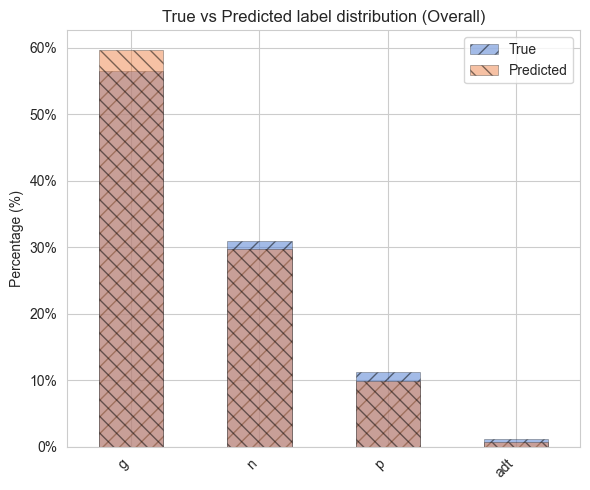

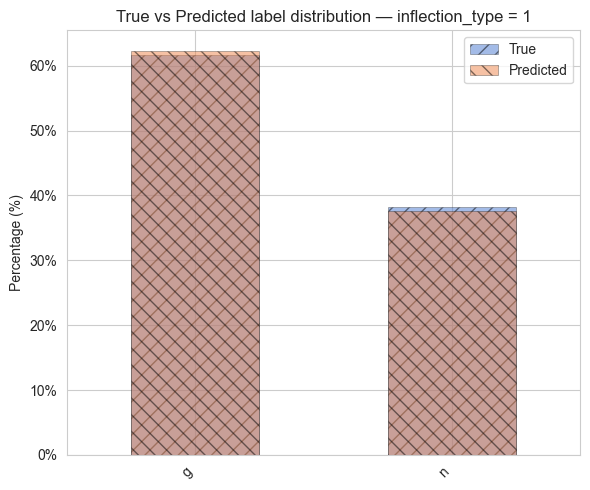

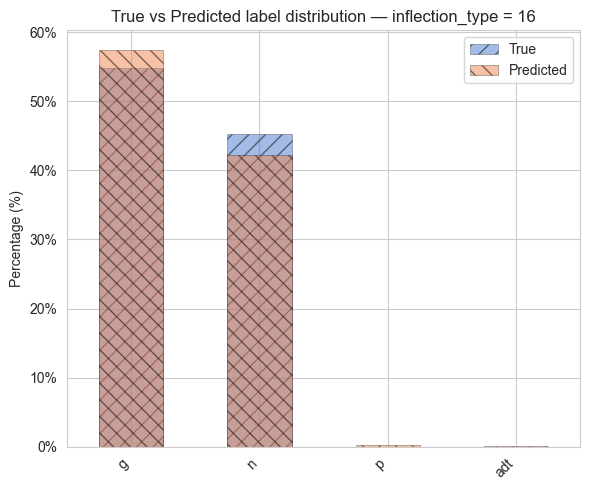

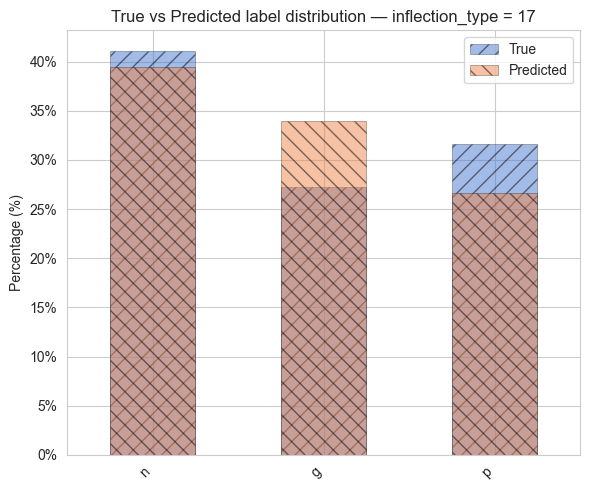

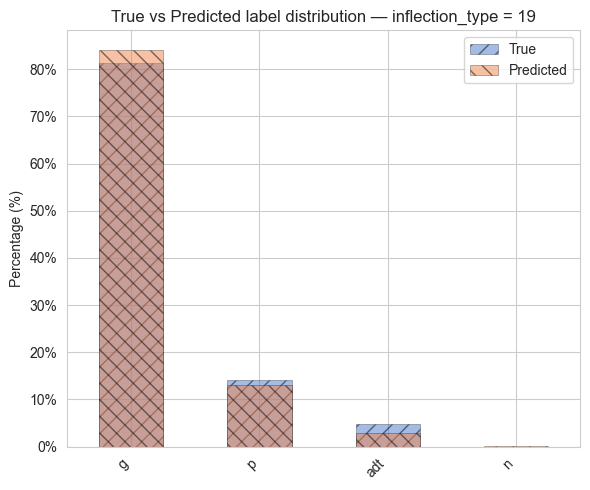

In [27]:
plot_true_vs_pred_by_inflection(
    results_df_filtered_possibles,
    label_col="true_case_lenient",
    pred_col="pred_case_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar_lenient_case_possibles",
)

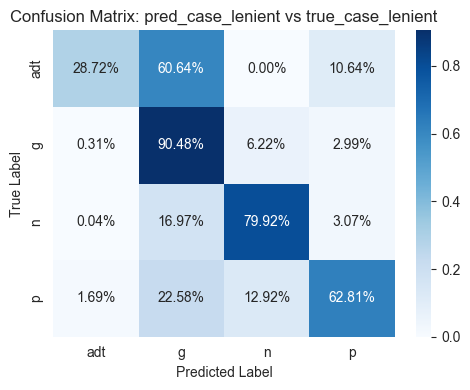

In [28]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    fig_size=(5, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case_possibles.png"
    ),
    significant_pred_threshold_pct=0,
)

In [29]:
# Generate results per inflection type
print(f"{model_name} results per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=True,
    show_classification_report=False,
)

Vabamorf_first results per inflection type:
inflection_type=1
Accuracy:  87.07%
Precision: 87.04%
Recall:    87.07%
F1-score:  87.05%
inflection_type=16
Accuracy:  87.66%
Precision: 88.17%
Recall:    87.66%
F1-score:  87.85%
inflection_type=17
Accuracy:  72.97%
Precision: 73.89%
Recall:    72.97%
F1-score:  73.01%
inflection_type=19
Accuracy:  85.17%
Precision: 84.23%
Recall:    85.17%
F1-score:  84.55%


In [30]:
# Generate classification reports per inflection type
print(f"{model_name} classification reports per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=False,
    show_classification_report=True,
)

Vabamorf_first classification reports per inflection type:
inflection_type=1 - Classification Report
              precision    recall  f1-score   support

        sg g       0.89      0.90      0.90      1232
        sg n       0.84      0.82      0.83       764

    accuracy                           0.87      1996
   macro avg       0.86      0.86      0.86      1996
weighted avg       0.87      0.87      0.87      1996

inflection_type=16 - Classification Report
              precision    recall  f1-score   support

         adt       0.00      0.00      0.00         0
           o       0.00      0.00      0.00         0
       sg es       0.00      0.00      0.00         0
        sg g       0.87      0.91      0.89      1080
        sg n       0.89      0.83      0.86       890
        sg p       0.00      0.00      0.00         0

    accuracy                           0.88      1970
   macro avg       0.29      0.29      0.29      1970
weighted avg       0.88      0.88      0.

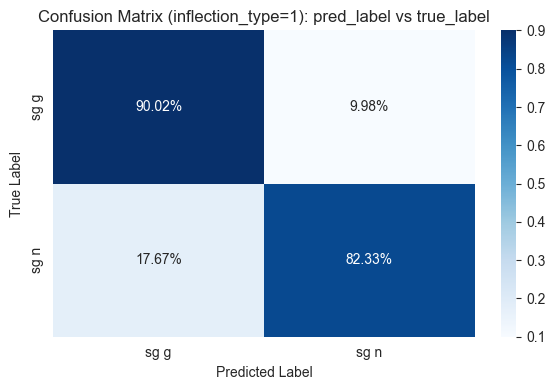

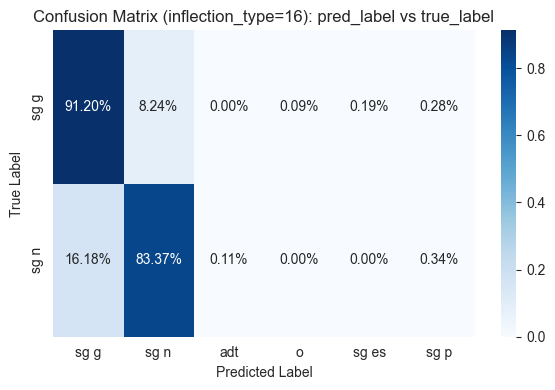

Confusion Matrix (inflection_type=16): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 sg p      6       0.30              True              0
1                sg es      2       0.10              True              0
2                    o      1       0.05              True              0
3                  adt      1       0.05              True              0
Sum of true labels count: 1970


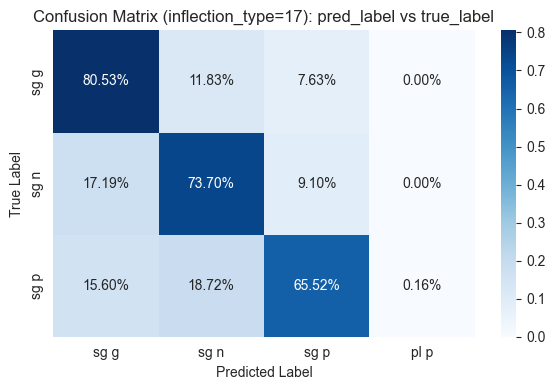

Confusion Matrix (inflection_type=17): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 pl p      1       0.05              True              0
Sum of true labels count: 1924


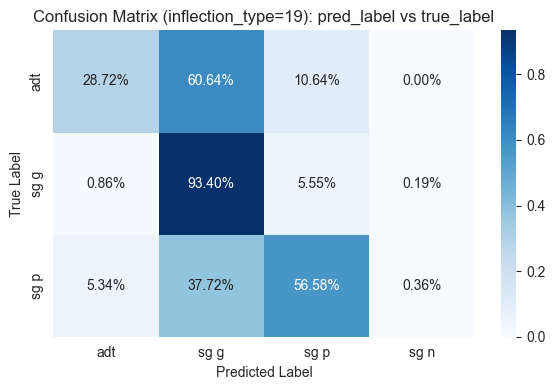

Confusion Matrix (inflection_type=19): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 sg n      4        0.2              True              0
Sum of true labels count: 1996


In [32]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_infl.png"),
    significant_pred_threshold_pct=0,
)

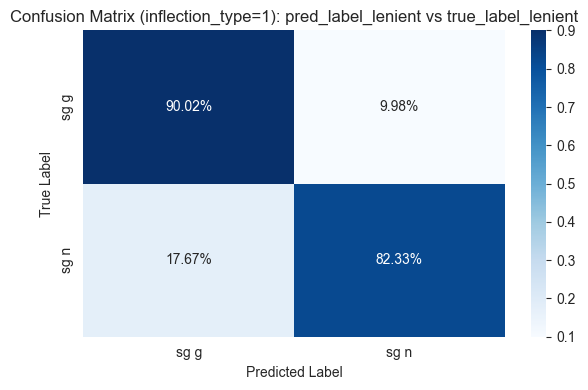

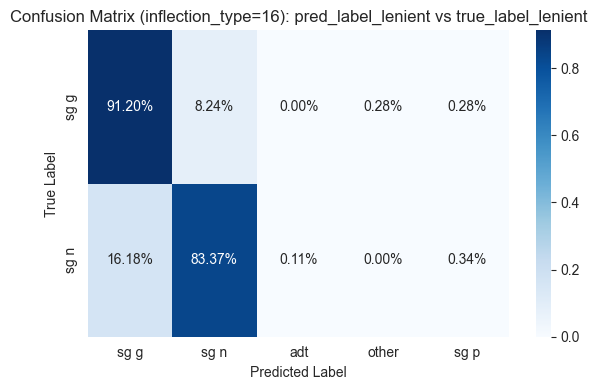

Confusion Matrix (inflection_type=16): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 sg p      6       0.30              True              0
1                other      3       0.15              True              0
2                  adt      1       0.05              True              0
Sum of true labels count: 1970


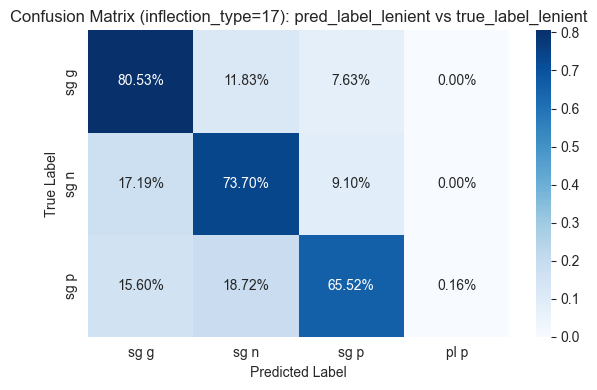

Confusion Matrix (inflection_type=17): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 pl p      1       0.05              True              0
Sum of true labels count: 1924


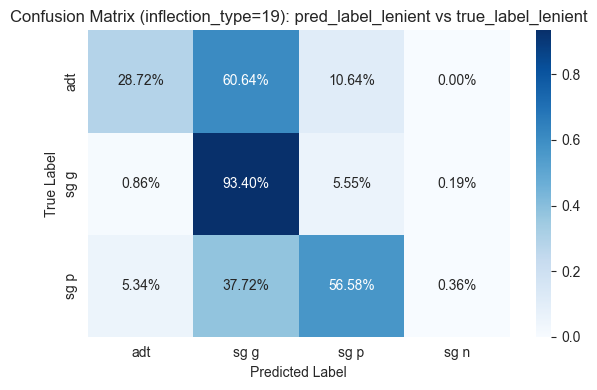

Confusion Matrix (inflection_type=19): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 sg n      4        0.2              True              0
Sum of true labels count: 1996


In [33]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_label_lenient",
    true_col="true_label_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

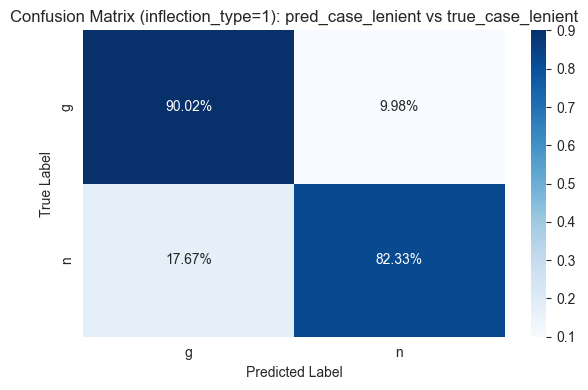

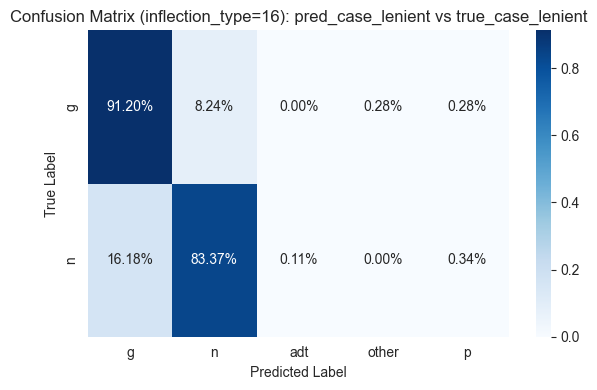

Confusion Matrix (inflection_type=16): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    p      6       0.30              True              0
1                other      3       0.15              True              0
2                  adt      1       0.05              True              0
Sum of true labels count: 1970


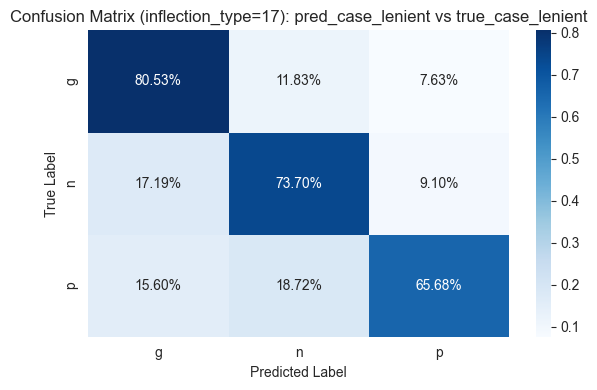

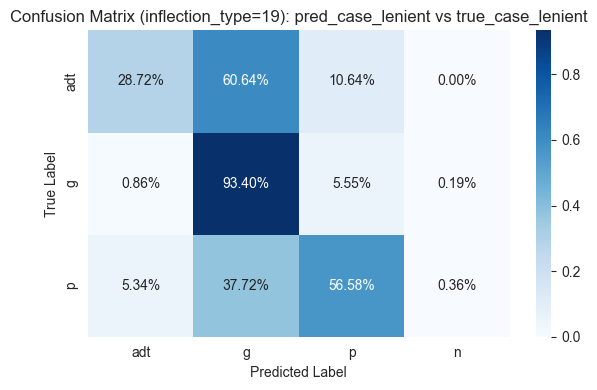

Confusion Matrix (inflection_type=19): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    n      4        0.2              True              0
Sum of true labels count: 1996


In [34]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

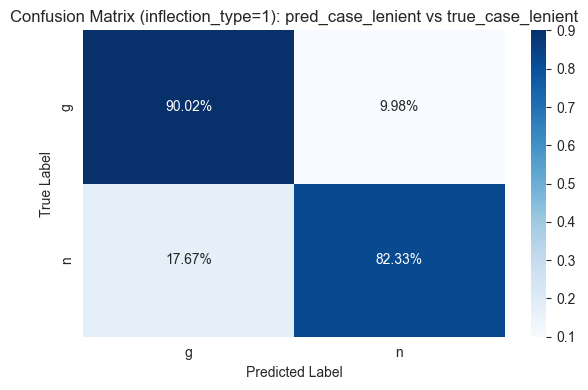

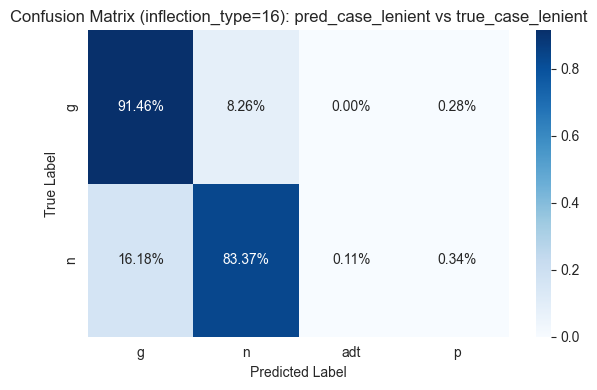

Confusion Matrix (inflection_type=16): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    p      6       0.31              True              0
1                  adt      1       0.05              True              0
Sum of true labels count: 1967


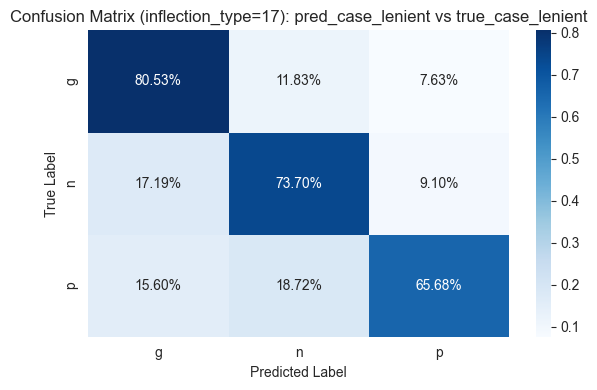

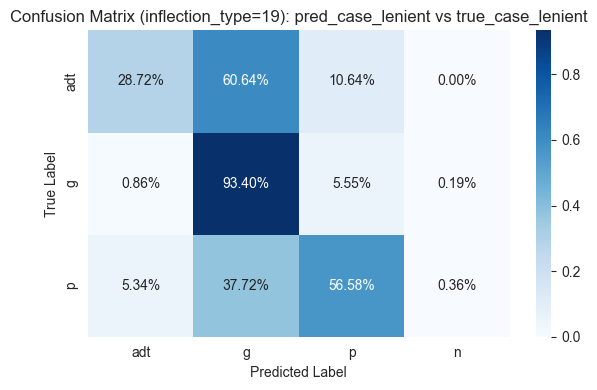

Confusion Matrix (inflection_type=19): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    n      4        0.2              True              0
Sum of true labels count: 1996


In [35]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR
        / model_name
        / f"{model_name}_CM_lenient_case_possibles_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

In [ ]:
# Analyse how many examples had multiple analyses in Vabamorf
ambiguous_count = results_df["ambiguous"].sum()
total_count = len(results_df)
print(
    f"Number of examples with multiple analyses in Vabamorf: {ambiguous_count} out of {total_count} ({ambiguous_count / total_count:.2%})"
)

Number of examples with multiple analyses in Vabamorf: 149 out of 7886 (1.89%)


In [ ]:
# Analyse results where Vabamorf predicted wrong
incorrect_df = results_df[results_df["pred_label"] != results_df["true_label"]]
number_to_sample = 1
# Create a df of incorrect predictions by sampling 5 random examples per inflection type + label group
cols = [c for c in incorrect_df.columns if c not in ["inflection_type", "true_label"]]
examples_to_show = (
    incorrect_df.groupby(["inflection_type", "true_label"])[cols]
    .apply(
        lambda x: (
            x.sample(n=number_to_sample, random_state=SEED)
            if len(x) >= number_to_sample
            else x
        )
    )
    .reset_index(level=[0, 1])
    .reset_index(drop=True)
)
print("Examples of incorrect predictions by Vabamorf:")
display_examples(
    dataset=examples_to_show,
    num_examples=20,
    display_or_print="print",
    list_of_columns_to_show=examples_to_show.columns.tolist(),
)

Examples of incorrect predictions by Vabamorf:
Example 1 (index 0):
  inflection_type: 1
  true_label: sg g
  sentence: Kohtunik Toomepärgi kolleegid avastasid teadvusetu mehe kohtuniku Õismäe kodust.
  word: teadvusetu
  word_span: (np.int64(40), np.int64(50))
  pred_label: sg n
  ambiguous: False
  num: 1
----------------------------------------
Example 2 (index 1):
  inflection_type: 1
  true_label: sg n
  sentence: Menukamad poisinimed on Karl, Markus ja Martin, tüdrukunimed aga Anna, Sandra, Laura ja Hanna.
  word: Sandra
  word_span: (np.int64(71), np.int64(77))
  pred_label: sg g
  ambiguous: False
  num: 2
----------------------------------------
Example 3 (index 2):
  inflection_type: 16
  true_label: sg g
  sentence: Näiteks omas sügisel 2000 15-74-aastase elanikkonna seas 52% inimestest mobiili, samas kui Leedus oli sama näitaja 20% (BMF Gallup Media ja SIC Gallup Media sihtrühma uuring, sügis 2000).
  word: Media
  word_span: (np.int64(131), np.int64(136))
  pred_label: sg 

In [ ]:
# Analyse results where Vabamorf predicted "sg g", but the true label was "adt"
sg_g_as_adt = results_df[
    (results_df["pred_label"] == "sg g") & (results_df["true_label"] == "adt")
]
print(sg_g_as_adt["inflection_type"].value_counts())
print(sg_g_as_adt["word"].value_counts().head(5))
print()
display_examples(
    dataset=sg_g_as_adt,
    num_examples=20,
    display_or_print="print",
    list_of_columns_to_show=sg_g_as_adt.columns.tolist(),
)

inflection_type
19    57
Name: count, dtype: int64
word
muuseumi       7
komisjoni      7
Washingtoni    6
gümnaasiumi    4
restorani      4
Name: count, dtype: int64

Example 1 (index 2993):
  sentence: Jaapani ärimees Masahito Otsuka kulutas oma unelmale, maailma tuntuimate kunstiteoste reprodutseerimisele ja nende ebatavalisse uude muuseumi koondamisele, 400 miljonit dollarit.
  word: muuseumi
  word_span: (np.int64(133), np.int64(141))
  true_label: adt
  pred_label: sg g
  ambiguous: False
  num: 1
  inflection_type: 19
----------------------------------------
Example 2 (index 3002):
  sentence: "Ühe Euroopa sõidu ajal, kui arvati, et see idarahvas on natuke rumal, ja taheti presidendile tõlki, ütles Meri mikrofoni inglise keeles, et tal on vaja küsimusi, mitte tõlki!" lausub 7. klassi poiss Tõnis.
  word: mikrofoni
  word_span: (np.int64(112), np.int64(121))
  true_label: adt
  pred_label: sg g
  ambiguous: False
  num: 1
  inflection_type: 19
------------------------------------

In [ ]:
# Analyse results where Vabamorf predicted "sg p", but the true label was "adt"
sg_p_as_adt = results_df[
    (results_df["pred_label"] == "sg p") & (results_df["true_label"] == "adt")
]
print(sg_p_as_adt["inflection_type"].value_counts())
print(sg_p_as_adt["word"].value_counts().head(5))
print()
display_examples(
    dataset=sg_p_as_adt,
    num_examples=20,
    display_or_print="print",
    list_of_columns_to_show=sg_p_as_adt.columns.tolist(),
)

inflection_type
19    10
Name: count, dtype: int64
word
restorani    3
telefoni     2
koridori     1
alkoholi     1
Portugali    1
Name: count, dtype: int64

Example 1 (index 2955):
  sentence: Pärast mitmendat koputamist tulevad naabrid koridori.
  word: koridori
  word_span: (np.int64(44), np.int64(52))
  true_label: adt
  pred_label: sg p
  ambiguous: False
  num: 1
  inflection_type: 19
----------------------------------------
Example 2 (index 2981):
  sentence: Pealinna tänavail ringi uidates tungisid neist kolm restorani, kus lükkasid ümber laudu ja toole ning mugisid porgandeid.
  word: restorani
  word_span: (np.int64(52), np.int64(61))
  true_label: adt
  pred_label: sg p
  ambiguous: False
  num: 1
  inflection_type: 19
----------------------------------------
Example 3 (index 3113):
  sentence: Ameerika ülikoolid püüavad kaitsta verisulis elluastujaid alkoholi uppumast, Eesti kõrgkoolid seni mitte
  word: alkoholi
  word_span: (np.int64(58), np.int64(66))
  true_label: adt
 

In [ ]:
from estnltk.default_resolver import make_resolver

resolver = make_resolver()

ma = (
    estnltk.Text(
        "Küll aga ootasime ära valitsuse seisukoha, mis jõudis meie komisjoni eelmisel nädalal."
    )
    .tag_layer(resolver=resolver)
    .morph_analysis
)
html = getattr(ma, "_repr_html_", None)
if html:
    content = html()
    with open("morph_analysis.html", "w", encoding="utf-8") as f:
        f.write(content)
display(ma)

Layer(name='morph_analysis', attributes=('normalized_text', 'lemma', 'root', 'root_tokens', 'ending', 'clitic', 'form', 'partofspeech'), spans=SL[Span('Küll', [{'normalized_text': 'Küll', 'lemma': 'küll', 'root': 'küll', 'root_tokens': ['küll'], 'ending': '0', 'clitic': '', 'form': '', 'partofspeech': 'D'}]),
Span('aga', [{'normalized_text': 'aga', 'lemma': 'aga', 'root': 'aga', 'root_tokens': ['aga'], 'ending': '0', 'clitic': '', 'form': '', 'partofspeech': 'J'}]),
Span('ootasime', [{'normalized_text': 'ootasime', 'lemma': 'ootama', 'root': 'oota', 'root_tokens': ['oota'], 'ending': 'sime', 'clitic': '', 'form': 'sime', 'partofspeech': 'V'}]),
Span('ära', [{'normalized_text': 'ära', 'lemma': 'ära', 'root': 'ära', 'root_tokens': ['ära'], 'ending': '0', 'clitic': '', 'form': '', 'partofspeech': 'D'}]),
Span('valitsuse', [{'normalized_text': 'valitsuse', 'lemma': 'valitsus', 'root': 'valitsus', 'root_tokens': ['valitsus'], 'ending': '0', 'clitic': '', 'form': 'sg g', 'partofspeech': 'S'}]),
Span('seisukoha', [{'normalized_text': 'seisukoha', 'lemma': 'seisukoht', 'root': 'seisu_koht', 'root_tokens': ['seisu', 'koht'], 'ending': '0', 'clitic': '', 'form': 'sg g', 'partofspeech': 'S'}]),
Span(',', [{'normalized_text': ',', 'lemma': ',', 'root': ',', 'root_tokens': [','], 'ending': '', 'clitic': '', 'form': '', 'partofspeech': 'Z'}]),
Span('mis', [{'normalized_text': 'mis', 'lemma': 'mis', 'root': 'mis', 'root_tokens': ['mis'], 'ending': '0', 'clitic': '', 'form': 'sg n', 'partofspeech': 'P'}, {'normalized_text': 'mis', 'lemma': 'mis', 'root': 'mis', 'root_tokens': ['mis'], 'ending': '0', 'clitic': '', 'form': 'pl n', 'partofspeech': 'P'}]),
Span('jõudis', [{'normalized_text': 'jõudis', 'lemma': 'jõudma', 'root': 'jõud', 'root_tokens': ['jõud'], 'ending': 'is', 'clitic': '', 'form': 's', 'partofspeech': 'V'}]),
Span('meie', [{'normalized_text': 'meie', 'lemma': 'mina', 'root': 'mina', 'root_tokens': ['mina'], 'ending': '0', 'clitic': '', 'form': 'pl g', 'partofspeech': 'P'}]),
Span('komisjoni', [{'normalized_text': 'komisjoni', 'lemma': 'komisjon', 'root': 'komisjon', 'root_tokens': ['komisjon'], 'ending': '0', 'clitic': '', 'form': 'sg g', 'partofspeech': 'S'}]),
Span('eelmisel', [{'normalized_text': 'eelmisel', 'lemma': 'eelmine', 'root': 'eelmine', 'root_tokens': ['eelmine'], 'ending': 'l', 'clitic': '', 'form': 'sg ad', 'partofspeech': 'A'}]),
Span('nädalal', [{'normalized_text': 'nädalal', 'lemma': 'nädal', 'root': 'nädal', 'root_tokens': ['nädal'], 'ending': 'l', 'clitic': '', 'form': 'sg ad', 'partofspeech': 'S'}]),
Span('.', [{'normalized_text': '.', 'lemma': '.', 'root': '.', 'root_tokens': ['.'], 'ending': '', 'clitic': '', 'form': '', 'partofspeech': 'Z'}])])

In [5]:
# List a table of words with counts and their respective inflection type
word_counts = (
    results_df.groupby(["word", "inflection_type", "true_label"])
    .size()
    .reset_index(name="count")
)
display(
    word_counts[word_counts["true_label"] == "adt"]
    .sort_values(by="count", ascending=False)
    .head(10)
)

,word,inflection_type,true_label,count
1313,komisjoni,19,adt,9
1485,muuseumi,19,adt,9
1661,restorani,19,adt,9
977,Washingtoni,19,adt,6
1458,mikrofoni,19,adt,4
1113,gümnaasiumi,19,adt,4
806,Singapuri,19,adt,4
1557,ookeani,19,adt,4
1789,terminali,19,adt,3
1779,telefoni,19,adt,3


Overall results
Accuracy:  87.67%
Precision: 86.06%
Recall:    87.67%
F1-score:  85.13%


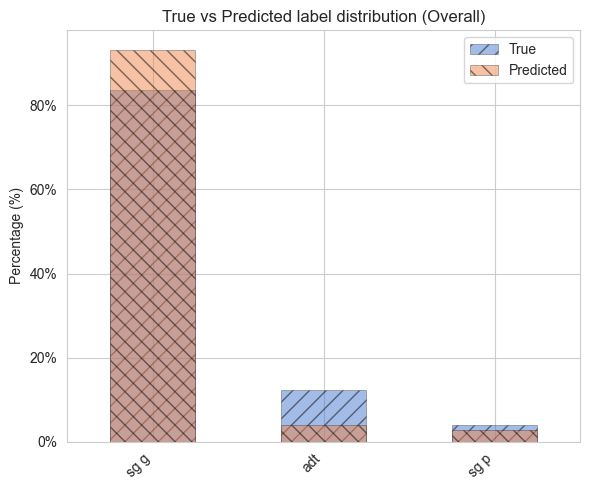

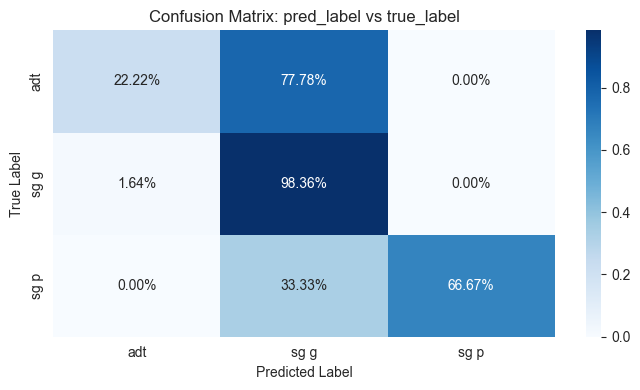

In [10]:
# Plot a barplot of the word "komisjon"
sona_df = results_df[results_df["word"] == "muuseumi"]
display_metrics_and_classification_report(
    results_df=sona_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)
plot_true_vs_pred_by_inflection(
    sona_df,
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=False,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_path),
    save_prefix=f"{model_path}_first_bar_sona_muuseumi",
)
plot_confusion_matrices(
    results_df=sona_df,
    pred_col="pred_label",
    true_col="true_label",
    fig_size=(7, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_path / f"{model_path}_first_CM_sona_muuseumi.png"
    ),
    significant_pred_threshold_pct=0,
)

<a id='tulemused_vabamorf_random'></a>


### Results Vabamorf (random)


In [36]:
model_name = "Vabamorf_random"

In [37]:
# Load results dataframe
results_df = pd.read_csv(
    df_random_output_csv_path,
    index_col=False,
)

results_df_split, results_df_filtered = (
    create_lenient_labels_and_split_counts_and_cases(
        results_df, "true_label", "pred_label"
    )
)

results_df_filtered_possibles = results_df_filtered[
    (results_df_filtered["true_case_lenient"] != "other")
    & (results_df_filtered["pred_case_lenient"] != "other")
]

print(f"{model_name} results:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)
print(f"\n{model_name} results (lenient):")
display_metrics_and_classification_report(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    show_metrics=True,
    show_classification_report=False,
)
print(f"\n{model_name} results (lenient, excluding 'other'):")
display_metrics_and_classification_report(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    show_metrics=True,
    show_classification_report=False,
)

# Count cases where "other" was predicted and the proportion of those out of all predictions
other_pred_count = (results_df_filtered["pred_case_lenient"] == "other").sum()
total_pred_count = len(results_df_filtered)
print(
    f'\nNumber of "other" cases: {other_pred_count} out of {total_pred_count} ({other_pred_count / total_pred_count:.2%})'
)

Vabamorf_random results:
Overall results
Accuracy:  83.31%
Precision: 82.94%
Recall:    83.31%
F1-score:  83.02%

Vabamorf_random results (lenient):
Overall results
Accuracy:  83.31%
Precision: 82.94%
Recall:    83.31%
F1-score:  83.02%

Vabamorf_random results (lenient, excluding 'other'):
Overall results
Accuracy:  83.34%
Precision: 82.94%
Recall:    83.34%
F1-score:  83.03%

Number of "other" cases: 3 out of 7886 (0.04%)


In [38]:
# Print classification reports
print(f"{model_name} classification report:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=False,
    show_classification_report=True,
)

Vabamorf_random classification report:
Overall results - Classification Report
              precision    recall  f1-score   support

         adt       0.47      0.29      0.36        94
           o       0.00      0.00      0.00         0
       sg es       0.00      0.00      0.00         0
        sg g       0.86      0.90      0.88      4457
        sg n       0.83      0.80      0.82      2445
        sg p       0.72      0.63      0.67       890

    accuracy                           0.83      7886
   macro avg       0.48      0.44      0.45      7886
weighted avg       0.83      0.83      0.83      7886



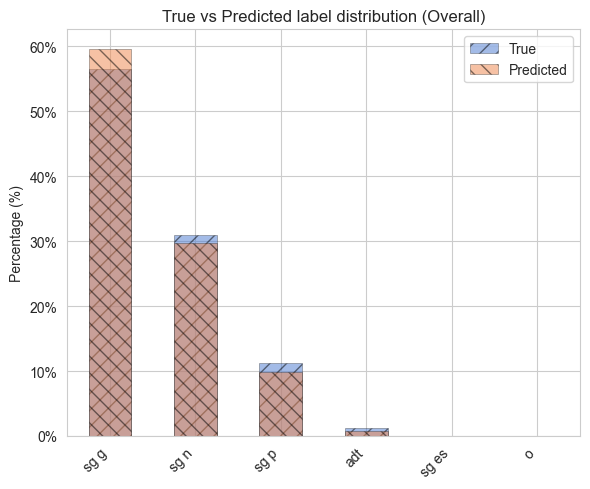

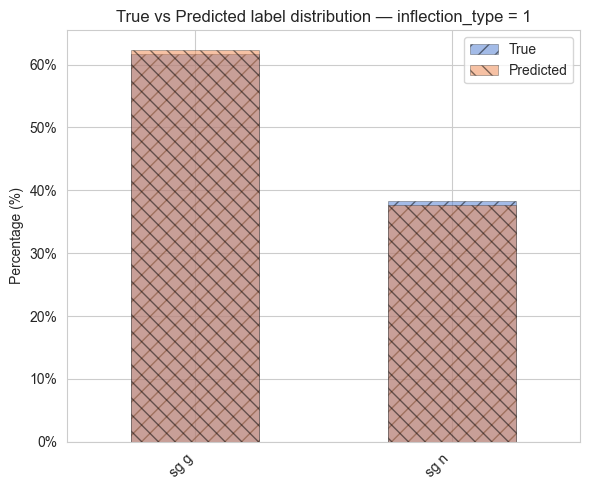

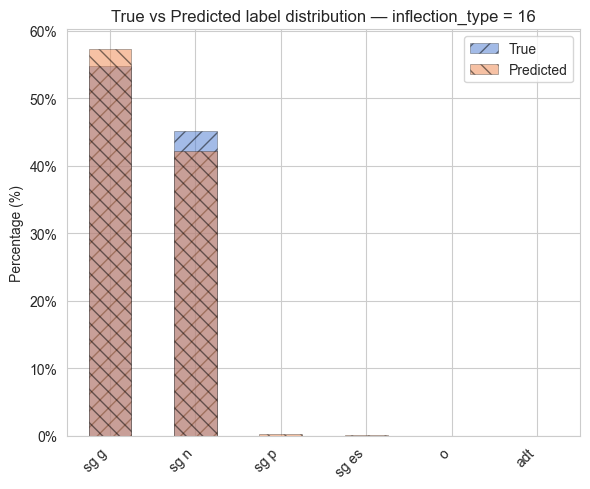

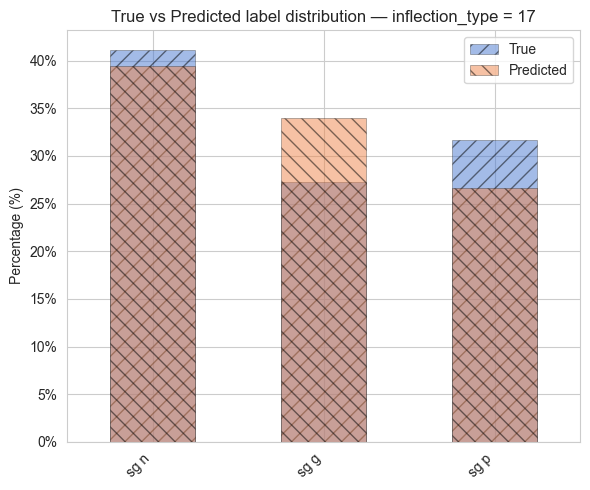

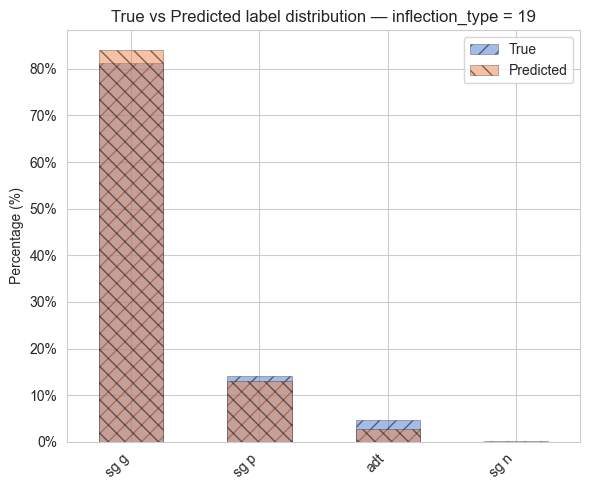

In [39]:
plot_true_vs_pred_by_inflection(
    results_df,
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar",
)

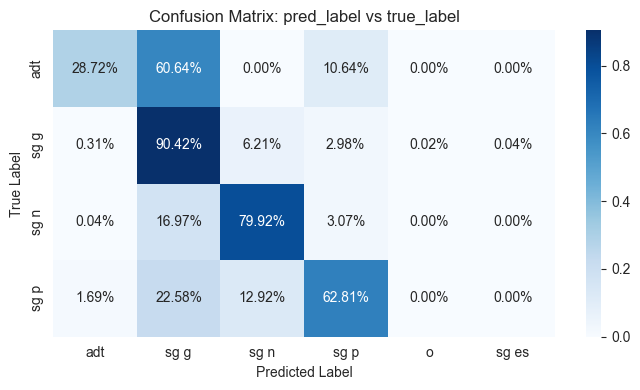

Confusion Matrix: pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                sg es      2       0.03              True              0
1                    o      1       0.01              True              0
Sum of true labels count: 7886


In [40]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    fig_size=(7, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM.png"),
    significant_pred_threshold_pct=0,
)

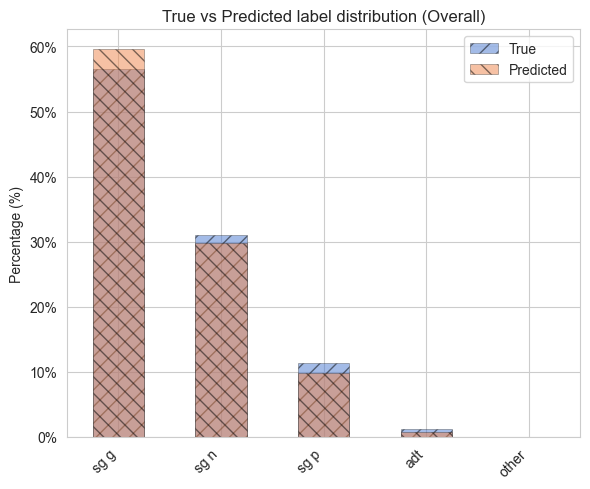

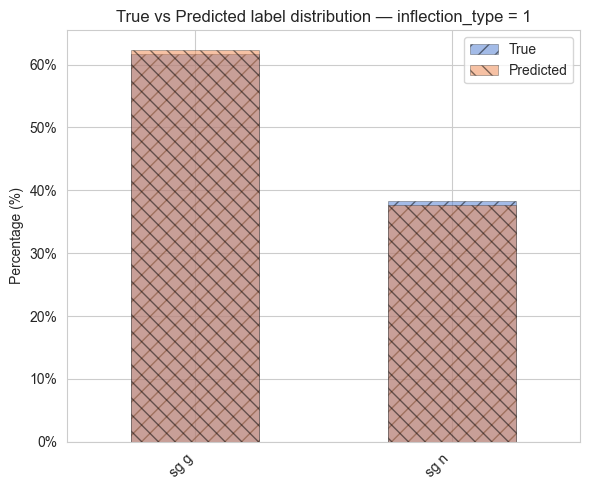

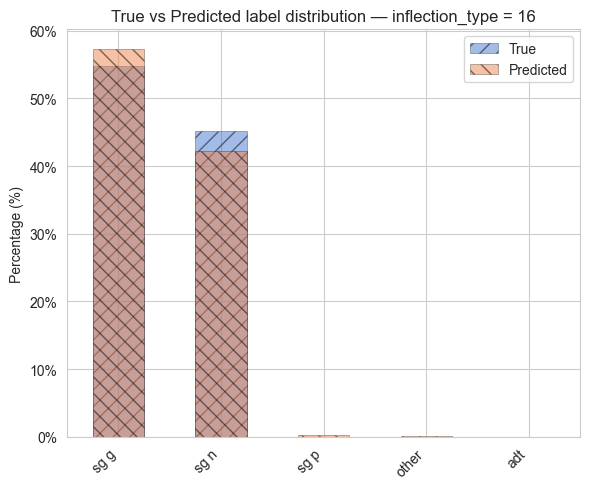

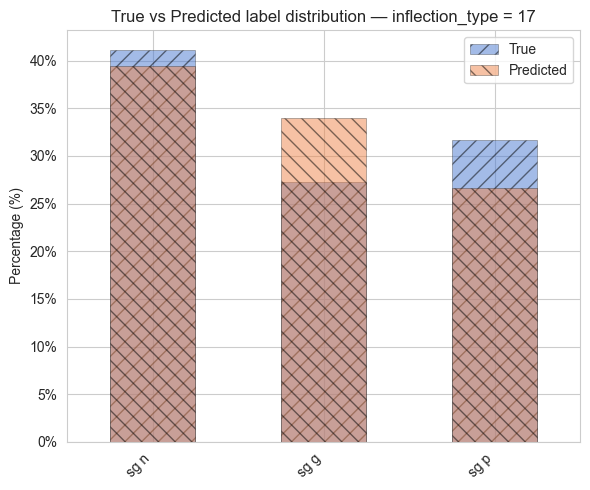

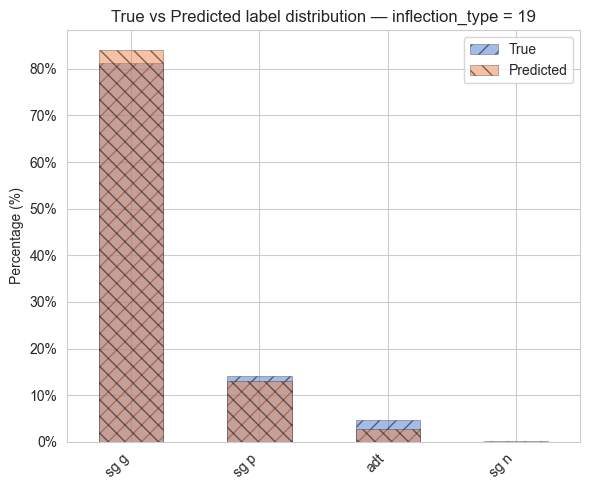

In [41]:
plot_true_vs_pred_by_inflection(
    results_df_filtered,
    label_col="true_label_lenient",
    pred_col="pred_label_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_lenient_bar",
)

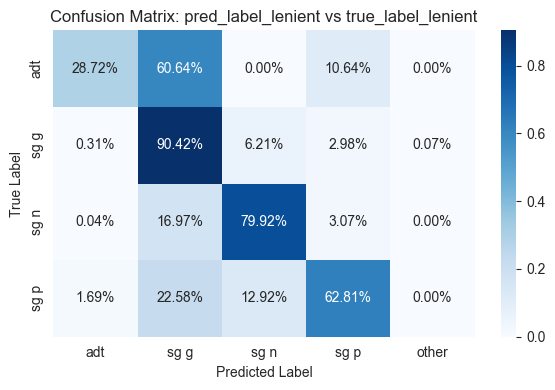

Confusion Matrix: pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other      3       0.04              True              0
Sum of true labels count: 7886


In [42]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_label_lenient",
    true_col="true_label_lenient",
    fig_size=(6, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient.png"),
    significant_pred_threshold_pct=0,
)

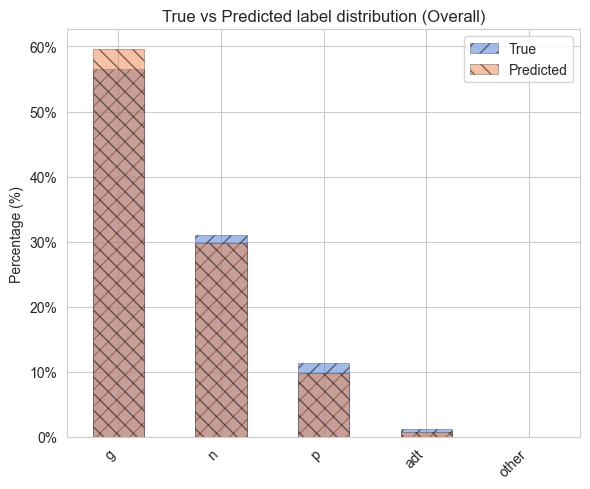

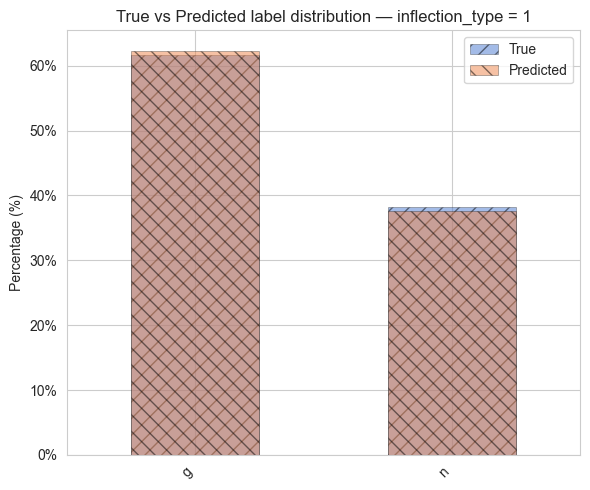

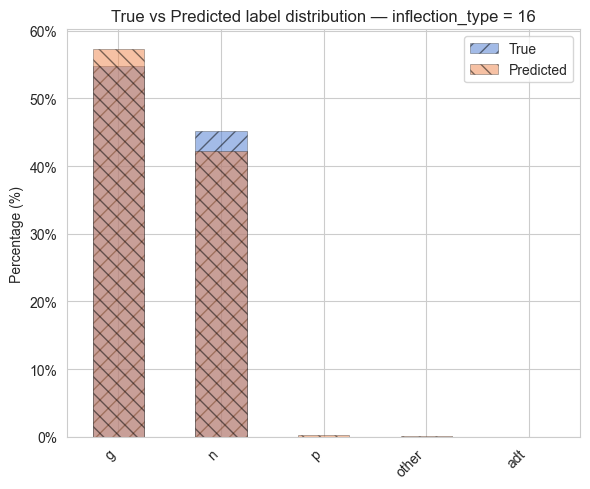

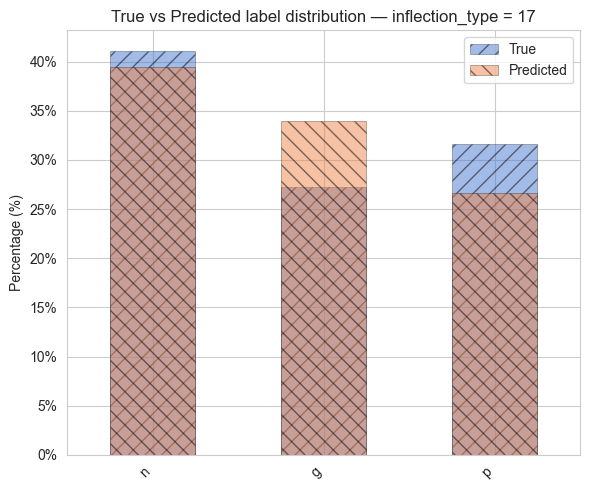

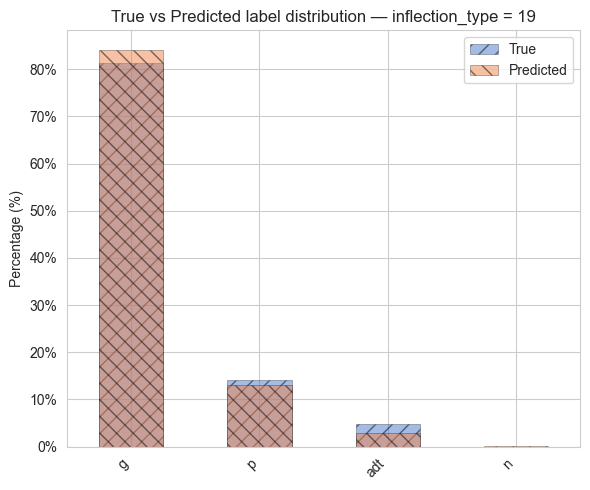

In [43]:
plot_true_vs_pred_by_inflection(
    results_df_filtered,
    label_col="true_case_lenient",
    pred_col="pred_case_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar_lenient_case",
)

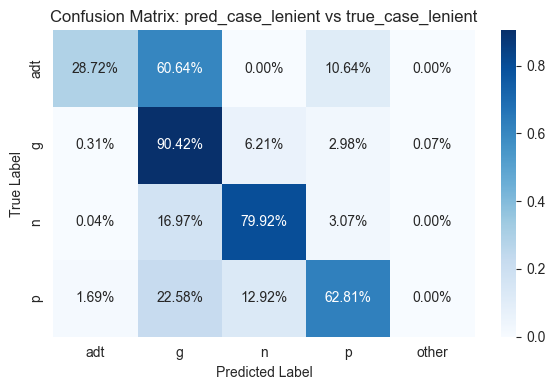

Confusion Matrix: pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other      3       0.04              True              0
Sum of true labels count: 7886


In [44]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case.png"
    ),
    significant_pred_threshold_pct=0,
)

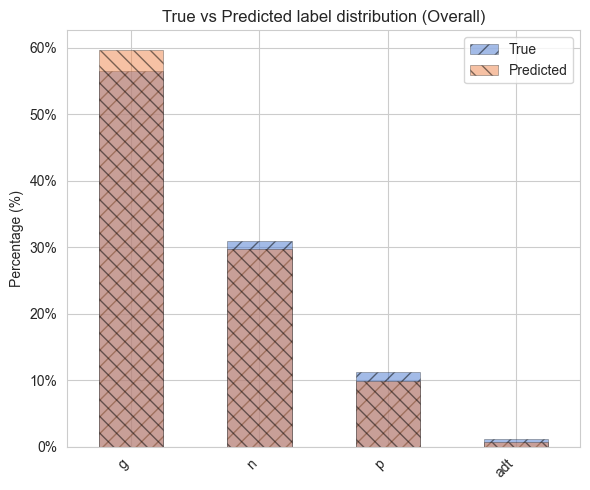

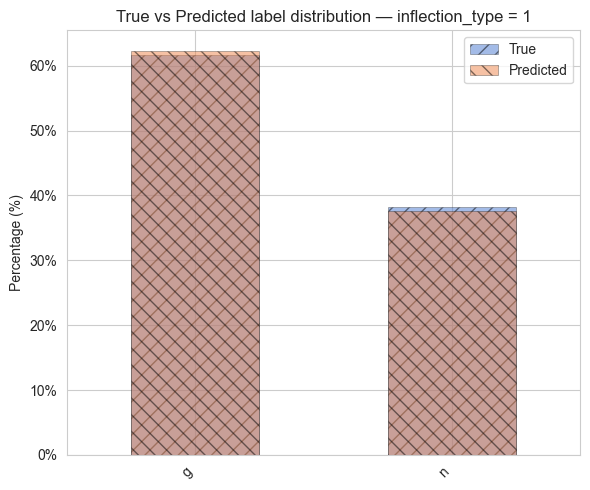

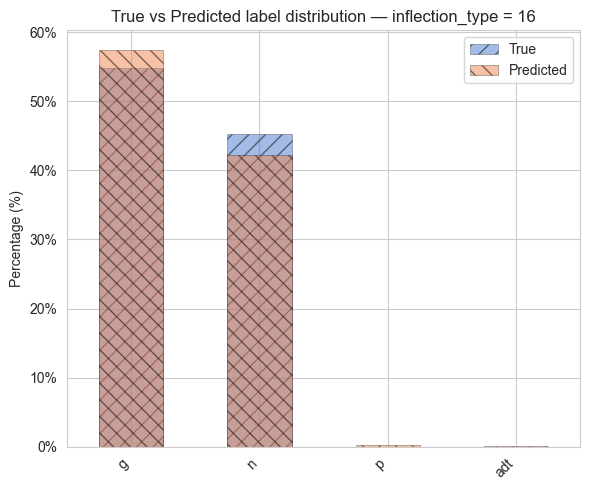

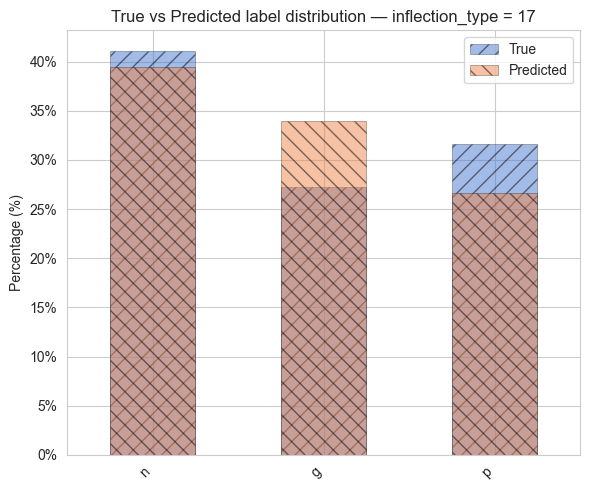

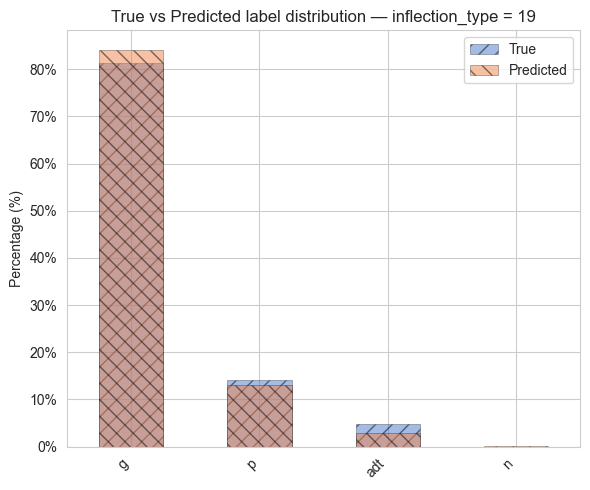

In [45]:
plot_true_vs_pred_by_inflection(
    results_df_filtered_possibles,
    label_col="true_case_lenient",
    pred_col="pred_case_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar_lenient_case_possibles",
)

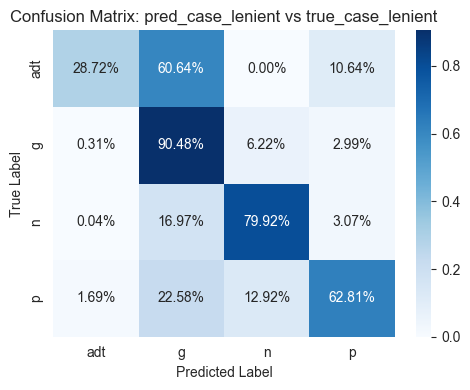

In [46]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    fig_size=(5, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case_possibles.png"
    ),
    significant_pred_threshold_pct=0,
)

In [47]:
# Generate results per inflection type
print(f"{model_name} results per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=True,
    show_classification_report=False,
)

Vabamorf_random results per inflection type:
inflection_type=1
Accuracy:  87.07%
Precision: 87.04%
Recall:    87.07%
F1-score:  87.05%
inflection_type=16
Accuracy:  87.66%
Precision: 88.17%
Recall:    87.66%
F1-score:  87.85%
inflection_type=17
Accuracy:  73.02%
Precision: 73.91%
Recall:    73.02%
F1-score:  73.05%
inflection_type=19
Accuracy:  85.17%
Precision: 84.23%
Recall:    85.17%
F1-score:  84.55%


In [48]:
# Generate classification reports per inflection type
print(f"{model_name} classification reports per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=False,
    show_classification_report=True,
)

Vabamorf_random classification reports per inflection type:
inflection_type=1 - Classification Report
              precision    recall  f1-score   support

        sg g       0.89      0.90      0.90      1232
        sg n       0.84      0.82      0.83       764

    accuracy                           0.87      1996
   macro avg       0.86      0.86      0.86      1996
weighted avg       0.87      0.87      0.87      1996

inflection_type=16 - Classification Report
              precision    recall  f1-score   support

         adt       0.00      0.00      0.00         0
           o       0.00      0.00      0.00         0
       sg es       0.00      0.00      0.00         0
        sg g       0.87      0.91      0.89      1080
        sg n       0.89      0.83      0.86       890
        sg p       0.00      0.00      0.00         0

    accuracy                           0.88      1970
   macro avg       0.29      0.29      0.29      1970
weighted avg       0.88      0.88      0

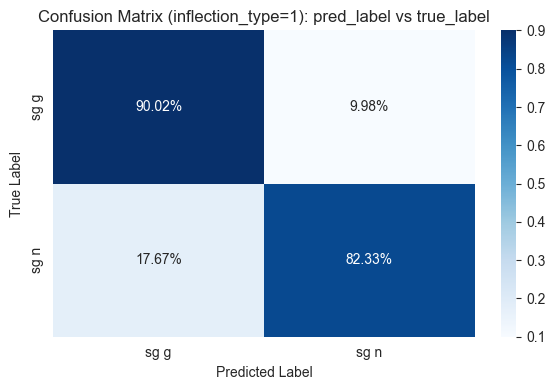

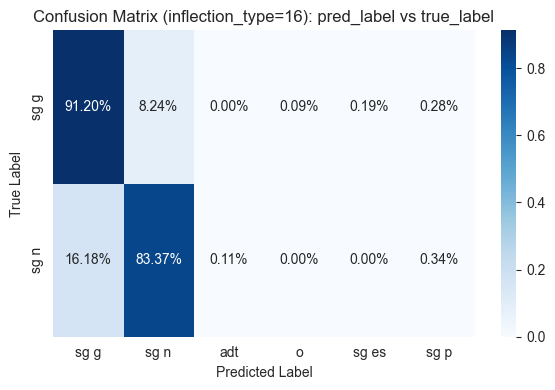

Confusion Matrix (inflection_type=16): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 sg p      6       0.30              True              0
1                sg es      2       0.10              True              0
2                    o      1       0.05              True              0
3                  adt      1       0.05              True              0
Sum of true labels count: 1970


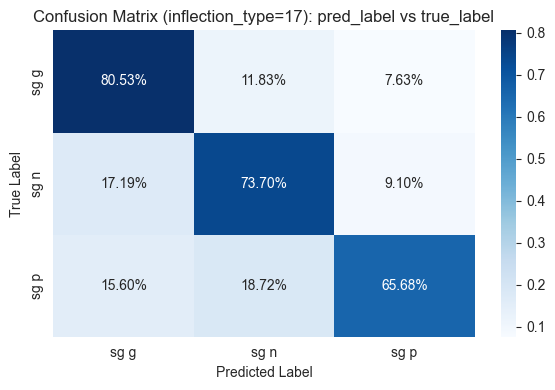

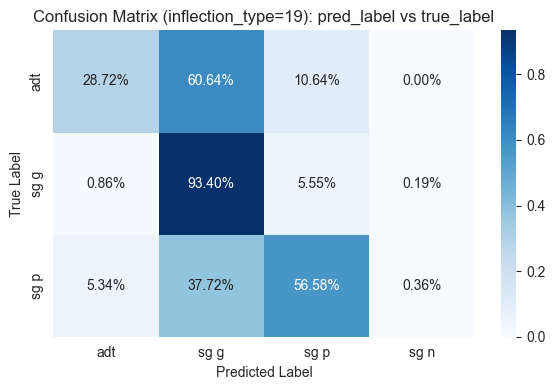

Confusion Matrix (inflection_type=19): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 sg n      4        0.2              True              0
Sum of true labels count: 1996


In [49]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_infl.png"),
    significant_pred_threshold_pct=0,
)

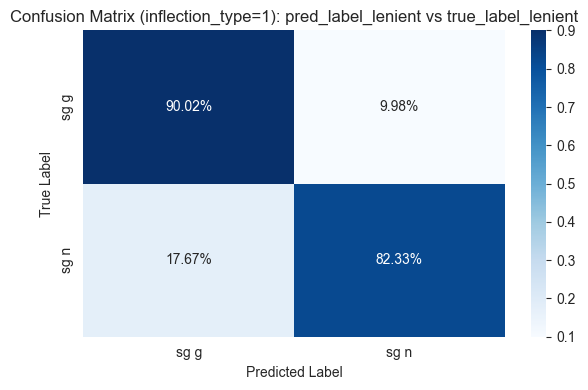

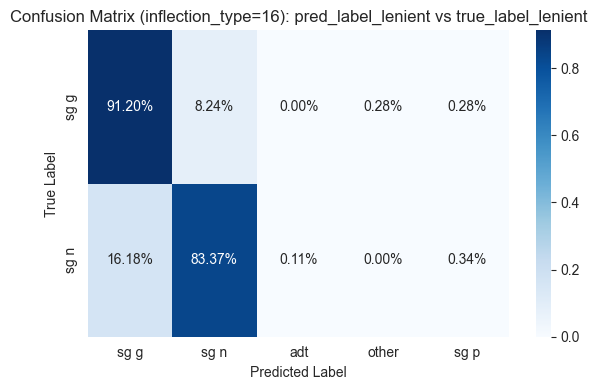

Confusion Matrix (inflection_type=16): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 sg p      6       0.30              True              0
1                other      3       0.15              True              0
2                  adt      1       0.05              True              0
Sum of true labels count: 1970


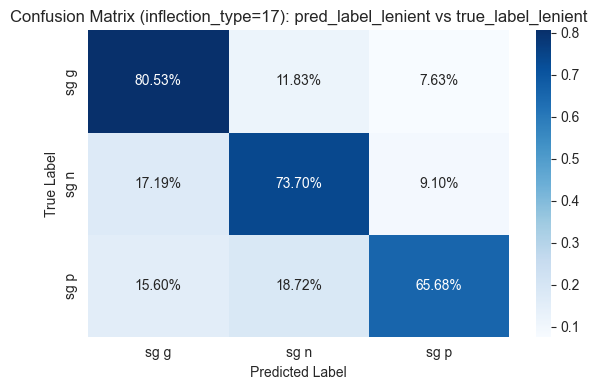

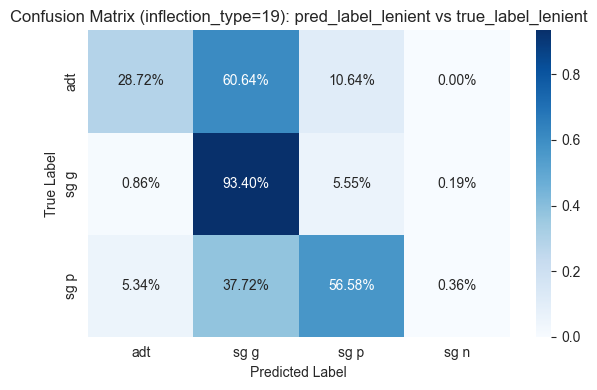

Confusion Matrix (inflection_type=19): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 sg n      4        0.2              True              0
Sum of true labels count: 1996


In [50]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_label_lenient",
    true_col="true_label_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

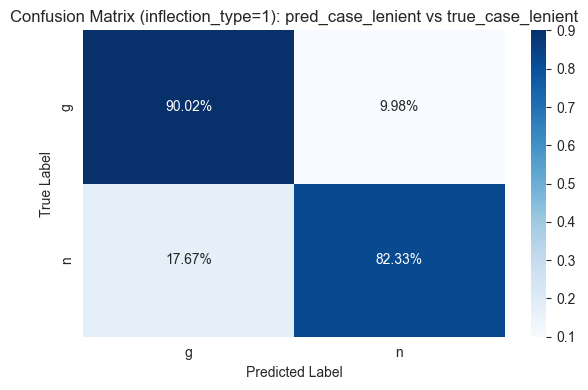

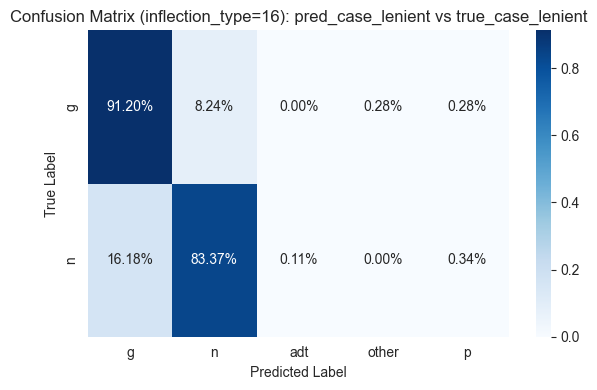

Confusion Matrix (inflection_type=16): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    p      6       0.30              True              0
1                other      3       0.15              True              0
2                  adt      1       0.05              True              0
Sum of true labels count: 1970


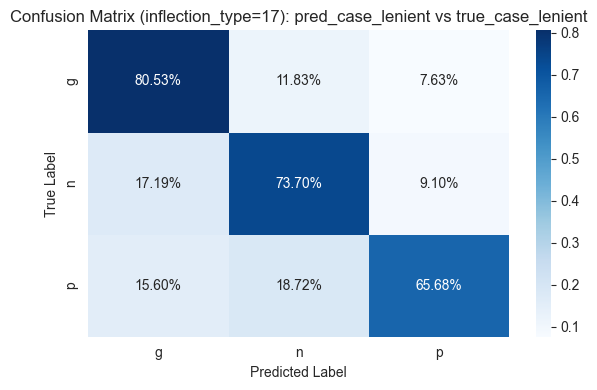

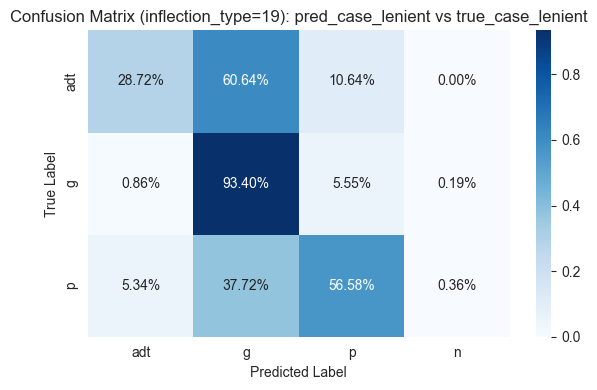

Confusion Matrix (inflection_type=19): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    n      4        0.2              True              0
Sum of true labels count: 1996


In [51]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

## END
